# Spatialize Evaluation Module

<span style="color: purple;">**This notebook has been tested with `spatialize v1.2.0`**</span>

This notebook demonstrates the full functionality of `spatialize.evaluation`, which provides different tools for evaluation the performance of interpolation models. These include:
- **Metrics**: continuous (MAE, RMSE, R², bias, operational variants) and categorical (accuracy, precision, recall, F1), with NaN handling.
- **Case studies** — `SyntheticScenario` (2D/3D, continuous/categorical) and `PrecipitationCaseStudy` (real 2.5D data), which provide a quick setup for testing models.
- **Cross-validation**: leave-one-out and k-fold, designed to evaluate any interpolation function at sampled locations.
- **Benchmark utilities**: scipy and kriging wrappers, including auto-selection.


## Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from spatialize.gs.esi import esi_nongriddata
from spatialize.gs.cat_esi import cat_esi_nongriddata
from spatialize.resources import ScientificColourMaps as SCM
import spatialize.gs.esi.lossfunction as lf

from spatialize.evaluation import (
    # Metrics — continuous
    error, absolute_error, bias,
    MAE, MSE, RMSE, R2,
    op_mae, op_rmse, op_mse,
    # Metrics — categorical
    accuracy, precision, recall, f1_score,
    # Cross-validation
    loo_validation, kfold_validation,
    # Benchmark
    scipy_prediction, auto_scipy_prediction, auto_krige,
    # Case studies
    SyntheticScenario, PrecipitationCaseStudy
)

## Part 1 - Metrics
`spatialize.evaluation` offers different metrics to evaluate the performance of interpolators in scenarios where ground truth is known (e.g. synthetic scenarios or controlled sampling).

### 1.1. Continuous Metrics

In [2]:
true  = np.array([1.0, 2.0, 3.0, 4.0, 5.0])
pred  = np.array([1.2, 1.8, 3.5, 3.9, 5.5])

print("Point-wise error  :", error(true, pred))
print("Absolute error    :", absolute_error(true, pred))
print()
print(f"Bias  : {bias(true, pred):.4f}  (positive → systematic over-prediction)")
print(f"MAE   : {MAE(true, pred):.4f}")
print(f"MSE   : {MSE(true, pred):.4f}")
print(f"RMSE  : {RMSE(true, pred):.4f}")
print(f"R²    : {R2(true, pred):.4f}")

Point-wise error  : [ 0.2 -0.2  0.5 -0.1  0.5]
Absolute error    : [0.2 0.2 0.5 0.1 0.5]

Bias  : 0.1800  (positive → systematic over-prediction)
MAE   : 0.3000
MSE   : 0.1180
RMSE  : 0.3435
R²    : 0.9410


#### Operational (normalised) Metrics

Operational metrics divide by the dynamic range of the true values, making them comparable across datasets with different scales.

In [3]:
print(f"OpMAE   : {op_mae(true, pred):.4f}")
print(f"OpRMSE  : {op_rmse(true, pred):.4f}")
print(f"OpMSE   : {op_mse(true, pred):.4f}")

OpMAE   : 0.0750
OpRMSE  : 0.0859
OpMSE   : 0.0295


#### NaN Handling

NaN values are common when interpolating values with scarce samples, so the metrics included in `spatialize.evaluation` silently ignore positions where either array is NaN.

In [4]:
true_nan = np.array([1.0, np.nan, 3.0, 4.0])
pred_nan = np.array([1.2,    2.0, 3.5, np.nan])

print(f"MAE with NaNs: {MAE(true_nan, pred_nan):.4f}  (only 2 valid pairs used)")

MAE with NaNs: 0.3500  (only 2 valid pairs used)


### 1.2. Categorical Metrics

`spatialize.evaluation` offers four wrappers for `scikit-learn` metrics which automatically filter NaN values.

All four metric receive true values and predicted values. `precision`, `recall` and `f1_score` also receive an `average` parameter, passed as sklearn's averaging stategy.

In [5]:
true_cat = np.array(["A", "B", "A", "C", "B", "A"])
pred_cat = np.array(["A", "B", "C", "C", "A", "A"])

print(f"Accuracy  : {accuracy(true_cat, pred_cat):.4f}")
print(f"Precision : {precision(true_cat, pred_cat):.4f}  (weighted)")
print(f"Recall    : {recall(true_cat, pred_cat):.4f}  (weighted)")
print(f"F1 score  : {f1_score(true_cat, pred_cat):.4f}  (weighted)")

Accuracy  : 0.6667
Precision : 0.7500  (weighted)
Recall    : 0.6667  (weighted)
F1 score  : 0.6667  (weighted)


#### Averaging strategies

In [6]:
for avg in ('weighted', 'macro', 'micro'):
    print(f"  {avg:8s}  precision={precision(true_cat, pred_cat, average=avg):.3f}"
          f"  recall={recall(true_cat, pred_cat, average=avg):.3f}"
          f"  f1={f1_score(true_cat, pred_cat, average=avg):.3f}")

  weighted  precision=0.750  recall=0.667  f1=0.667
  macro     precision=0.722  recall=0.722  f1=0.667
  micro     precision=0.667  recall=0.667  f1=0.667


## Part 2 — Case Studies
A set of synthetic case studies, as well as one real-life dataset are included for quick model performance evaluations.

### 2.1. Synthetic Scenarios
`SyntheticScenario` generates synthetic spatial data with known ground truth, enabling objective evaluation of interpolation methods.

#### 2D Continuous Scenario (non-gridded)

In [7]:
scenario_2d = SyntheticScenario(
    n_dims=2,
    extent=[0, 100, 0, 100],
    griddata=False
)

points, values, xi, reference = scenario_2d.simulate_scenario(
    kind='cubic', n_samples=150, seed=42
)

print(f"Sample points : {points.shape}")
print(f"Target grid   : {xi.shape}")
print(f"Reference     : {reference.shape}")

Sample points : (150, 2)
Target grid   : (10201, 2)
Reference     : (10201,)


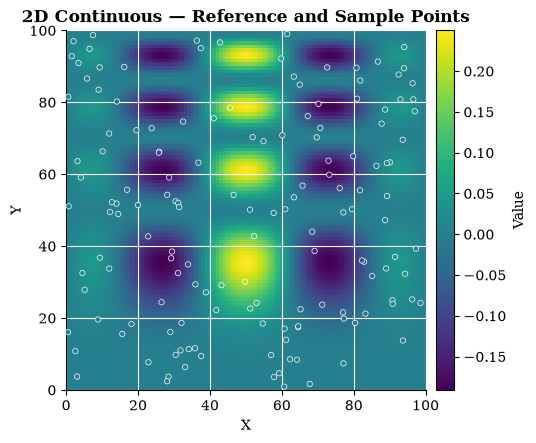

In [8]:
fig, ax = scenario_2d.plot_2d_scenario(
    points, values, xi, reference,
    theme='publication',
    title='2D Continuous — Reference and Sample Points',
)
plt.show()

#### 2D Gridded Continuous Scenario

In [9]:
scenario_grid = SyntheticScenario(
    n_dims=2,
    extent=[0, 1, 0, 1],
    griddata=True,
    n_grid_points=60,
)

pts_g, vals_g, xi_g, ref_g = scenario_grid.simulate_scenario(
    kind='cubic', n_samples=150, seed=0
)

print(f"Grid xi shape : {xi_g.shape}  (2 × nx × ny)")
print(f"Reference     : {ref_g.shape}")

Grid xi shape : (2, 60, 60)  (2 × nx × ny)
Reference     : (60, 60)


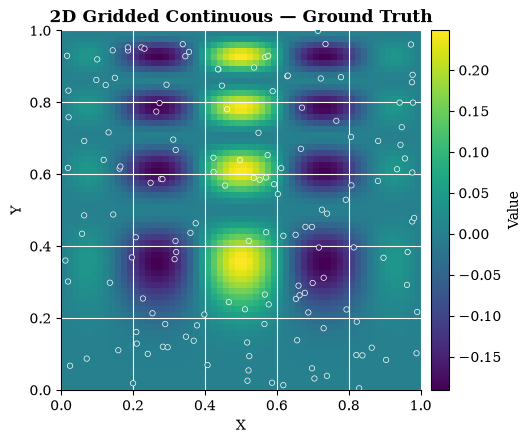

In [10]:
fig, ax = scenario_grid.plot_2d_scenario(
    pts_g, vals_g, xi_g, ref_g,
    theme='publication',
    title='2D Gridded Continuous — Ground Truth',
)
plt.show()

#### 2D Nominal Categorical Scenario

In [11]:
scenario_cat = SyntheticScenario(
    categorical=True,
    n_grid_points=80,
)

pts_c, vals_c, xi_c, ref_c = scenario_cat.simulate_scenario(
    kind='nominal', n_samples=100, seed=7
)

print(f"Unique classes : {np.unique(ref_c)}")

Unique classes : ['A' 'B' 'C' 'D']


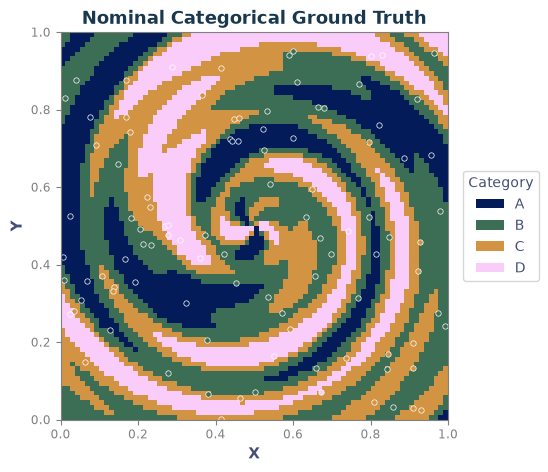

In [12]:
fig, ax = scenario_cat.plot_2d_scenario(
    pts_c, vals_c, xi_c, ref_c,
    title='Nominal Categorical Ground Truth',
    cmap='batlow'
)
plt.show()

#### 2D Ordinal Categorical Scenario

In [13]:
scenario_ord = SyntheticScenario(categorical=True, n_grid_points=80)

pts_o, vals_o, xi_o, ref_o = scenario_ord.simulate_scenario(
    kind='ordinal', n_samples=150, seed=7
)

ordinal_labels = list(SyntheticScenario.ORDINAL_ORDER)  # ['Low', 'Medium', 'High']
print(f"Ordinal classes : {ordinal_labels}")
print(f"Class counts    : { {k: int((ref_o == k).sum()) for k in ordinal_labels} }")

Ordinal classes : ['Low', 'Medium', 'High']
Class counts    : {'Low': 2113, 'Medium': 2197, 'High': 2090}


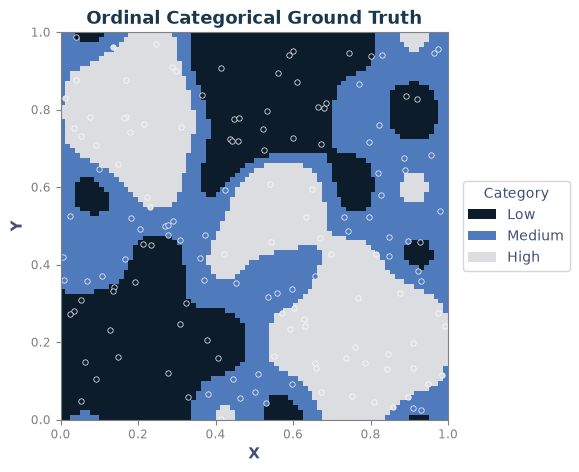

In [14]:
fig, ax = scenario_ord.plot_2d_scenario(
    pts_o, vals_o, xi_o, ref_o,
    nonnum_order=ordinal_labels,
    title='Ordinal Categorical Ground Truth',
)
plt.show()

#### 3D Continuous Scenario

In [15]:
scenario_3d = SyntheticScenario(
    n_dims=3,
    extent=[0, 10, 0, 10, 0, 5],
    griddata=False,
    n_grid_points=(20, 20, 10),
)

pts_3, vals_3, xi_3, ref_3 = scenario_3d.simulate_scenario(
    kind='cubic', n_samples=400, seed=99
)

print(f"Sample points : {pts_3.shape}")
print(f"Target grid   : {xi_3.shape}  ({20*20*10} total locations)")

Sample points : (400, 3)
Target grid   : (4000, 3)  (4000 total locations)


#### Custom Function Scenario

You can inject your own ground-truth function via `custom_func`:

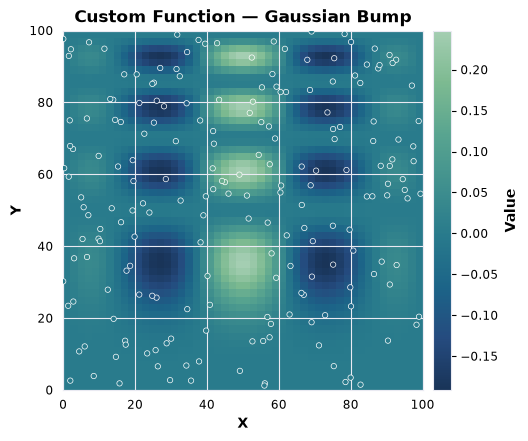

In [16]:
def gaussian_bump(x, y, cx=50, cy=50, sigma=15):
    return np.exp(-((x - cx)**2 + (y - cy)**2) / (2 * sigma**2))

scenario_custom = SyntheticScenario(
    n_dims=2, extent=[0, 100, 0, 100], griddata=False, n_grid_points=50
)

pts_cu, vals_cu, xi_cu, ref_cu = scenario_custom.simulate_scenario(
    n_samples=200, seed=1,
    custom_func=gaussian_bump,
    custom_func_params={'cx': 50, 'cy': 50, 'sigma': 15},
)

fig, ax = scenario_custom.plot_2d_scenario(
    pts_cu, vals_cu, xi_cu, ref_cu,
    title='Custom Function — Gaussian Bump',
    theme='whitegrid',
)
plt.show()

### 2.2. Precipitation Case Study (Real 2.5D Data)

`PrecipitationCaseStudy` wraps the Maipo Basin precipitation dataset. Sample points have 3D coordinates (UTM East, UTM North, elevation) and the target is precipitation at unsampled locations. data for 3 different dates is included. 

#### Loading and Visualizing Data
**Note**: Visualizing the precipitation case study requires `geopandas` and `seaborn` to be installed.

In [17]:
case_study = PrecipitationCaseStudy(data_cmap=SCM.navia_r, locs_cmap=SCM.glasgow)

print(f"Dates: {case_study.dates}")

Dates: ['2018-07-04', '2018-07-05', '2018-07-06']


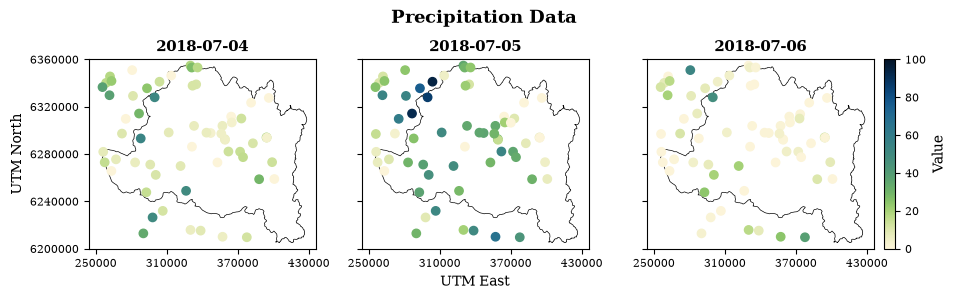

In [18]:
fig, axs = case_study.plot_input_data()
plt.tight_layout()
plt.show()

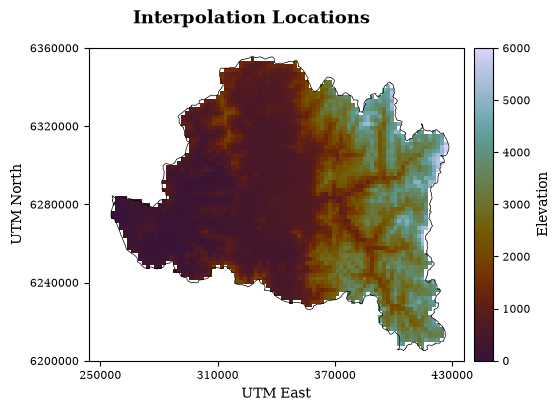

In [19]:
fig, ax = case_study.plot_interpolation_locations()
plt.show()

#### Running ESI for all three dates

In [20]:
# for ESI precision estimations
points_pp, values_pp, xi_pp = case_study.model_inputs()

esi_results_df = case_study.locs.copy()
esi_results_df.columns = pd.MultiIndex.from_tuples(
    [(c, '') for c in esi_results_df.columns]
)

for date in case_study.dates:
    result = esi_nongriddata(
        points=points_pp[date],
        values=values_pp[date],
        xi=xi_pp,
        local_interpolator='idw',
        n_partitions=300,
        alpha=0.8,
        exponent=2.0,
        seed=42,
    )

    esi_results_df[(date, 'value')]     = result.estimation()
    esi_results_df[(date, 'precision')] = result.precision(lf.OperationalErrorLoss(values_pp[date].max()-values_pp[date].min()))

finished 100% of 300 iterations ... 

done (elapsed time:  8s)
finished 100% of 300 iterations ... 

done (elapsed time:  7s)
finished 100% of 300 iterations ... 

done (elapsed time:  6s)


#### Visualising ESI Results

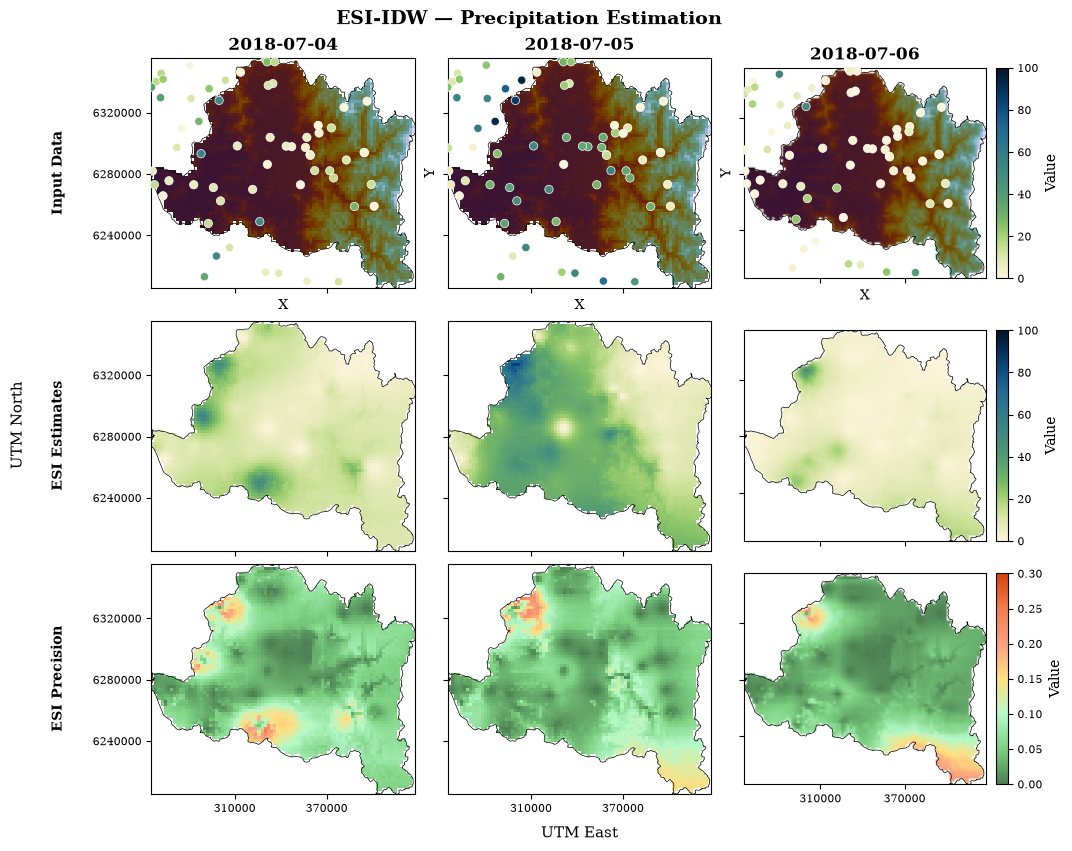

In [21]:
fig, axs = case_study.plot_esi_results(
    esi_results_df,
    parameters=None,
    local_interpolator='idw',
    precision_function='Operational MAE',
    fig_title='ESI-IDW — Precipitation Estimation',
)
plt.show()

#### Model Comparison

Compare ESI against scipy interpolation methods for a single date.

**Note**: `scipy_prediction` (used here) is introduced in Part 4.

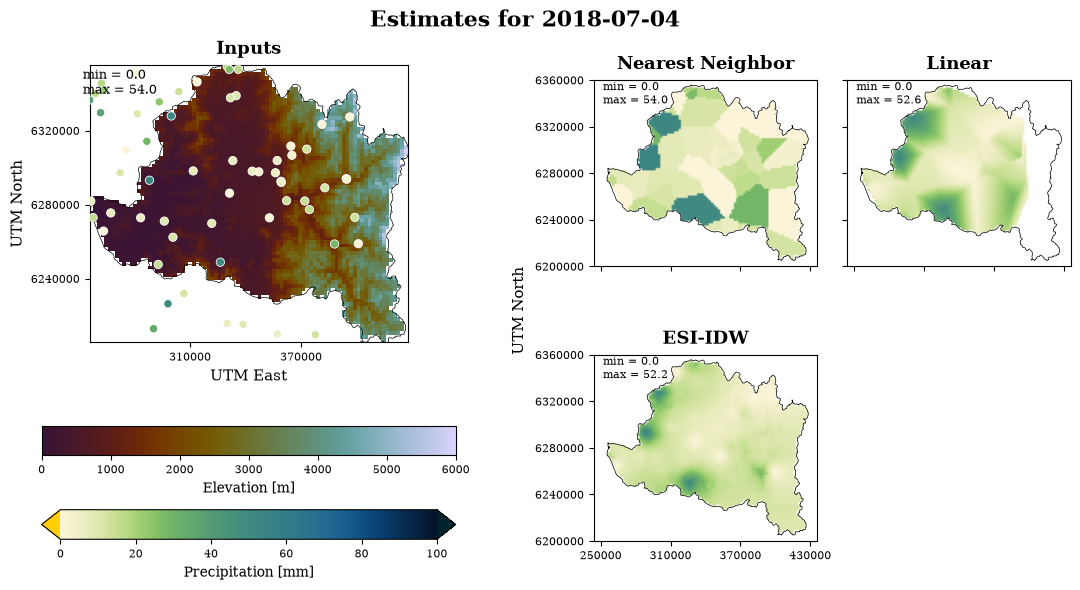

In [22]:
date = case_study.dates[0]

locs_xy = case_study.locs[['X', 'Y']].values

# Build a comparison results frame expected by plot_model_comparison
comp_df = case_study.locs.copy()

for method in ('nearest', 'linear'):
    est = scipy_prediction(
        points_pp[date][:, :2],   # use only x,y for scipy
        values_pp[date],
        locs_xy,
        method=method,
    )
    comp_df[(method, date, 'value')] = est

# ESI already computed above
comp_df[('esi', date, 'value')] = esi_results_df[(date, 'value')].values

fig, subfigs, ax0, axs_cmp = case_study.plot_model_comparison(
    comp_df, date=date,
    interpolators=['nearest', 'linear', 'esi'],
    names=['Nearest Neighbor', 'Linear', 'ESI-IDW'],
)
plt.show()

## Part 3 — Cross-Validation
For applications where ground truth is not available, `spatialize.evaluation` offers two cross-validation functions for evaluating the performance of interpolators.

### 3.1. Leave-One-Out Validation

`loo_validation` evaluates any interpolation callable using LOO. It receives:
- `points`: locations of the samples
- `values`: values of the samples
- `interpolation_function`: a callable interpolation function
- `metrics`: list of metrics to be computed
- `return_predictions`: whether to return only calculated metrics (False, default) or also return the leave-one-out predictions (True)

Any other passed arguments are forwarded to the interpolator. The callable must have the signature `f(points, values, xi, **kwargs) -> array`.

In [23]:
# callable
def esi_predict(pts, vals, xi_, **kw):
    return esi_nongriddata(pts, vals, xi_, **kw).estimation()

# Leave-one-out validation (default configuration)
loo_results = loo_validation(
    points, values,
    interpolation_function=esi_predict,     # callable interpolator here
    metrics=[MAE, RMSE, R2],
    # ESI kwargs:
    local_interpolator='idw',
    n_partitions=100,
    alpha=0.8,
    exponent=2.0,
)

# the function returns a dictionary contasining the metrics.
print("LOO results:")
for name, val in loo_results.items():
    print(f"  {name:6s}: {val:.4f}")

LOO results:
  MAE   : 0.0217
  RMSE  : 0.0380
  R2    : 0.5816


#### LOO with predictions array
If needed, setting `return_predictions` to True to return the metrics as well as the raw loo predictions.

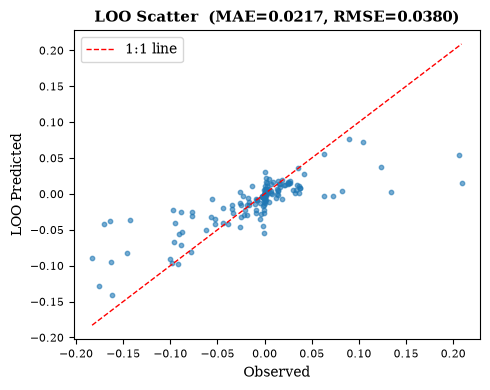

In [24]:
# loo
loo_results2, loo_preds = loo_validation(
    points, values,
    esi_predict,
    metrics=[MAE, RMSE],
    return_predictions=True,            # here
    local_interpolator='idw',
    n_partitions=100,
    alpha=0.8,
    exponent=2.0,
)

# here, we'll use the values to visualize true vs pred
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(values, loo_preds, s=10, alpha=0.6)
ax.plot([values.min(), values.max()], [values.min(), values.max()],
        'r--', lw=1, label='1:1 line')
ax.set_xlabel('Observed')
ax.set_ylabel('LOO Predicted')
ax.set_title(f"LOO Scatter  (MAE={loo_results2['MAE']:.4f}, RMSE={loo_results2['RMSE']:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

### 3.2. K-Fold Cross-Validation
As an alternative to leave-one-out, `kfold_validation`performs k-fols cross-validation, where parameter `k` controlls the number of folds, and `seed` the folding configuration.

In [25]:
kfold_results = kfold_validation(
    points, values,
    esi_predict,
    k=5,
    metrics=[MAE, RMSE, R2],
    seed=42,
    local_interpolator='idw',
    n_partitions=100,
    alpha=0.8,
    exponent=2.0,
)

print("5-fold CV results:")
for name, val in kfold_results.items():
    print(f"  {name:6s}: {val:.4f}")

5-fold CV results:
  MAE   : 0.0229
  RMSE  : 0.0392
  R2    : 0.5534


#### K-fold with out-of-fold predictions

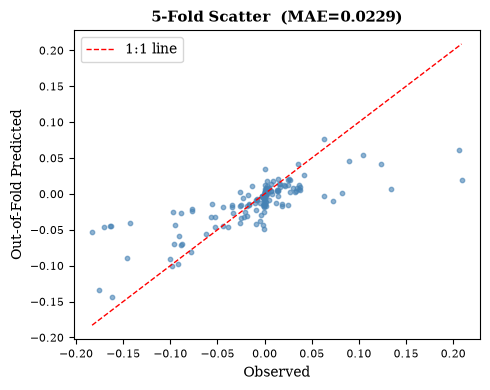

In [26]:
kfold_results2, kfold_preds = kfold_validation(
    points, values,
    esi_predict,
    k=5, seed=42,
    metrics=[MAE, RMSE],
    return_predictions=True,
    local_interpolator='idw',
    n_partitions=100,
    alpha=0.8,
    exponent=2.0,
)

fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(values, kfold_preds, s=10, alpha=0.6, color='steelblue')
ax.plot([values.min(), values.max()], [values.min(), values.max()],
        'r--', lw=1, label='1:1 line')
ax.set_xlabel('Observed')
ax.set_ylabel('Out-of-Fold Predicted')
ax.set_title(f"5-Fold Scatter  (MAE={kfold_results2['MAE']:.4f})")
ax.legend()
plt.tight_layout()
plt.show()

### 3.3. Categorical Cross-Validation
The cross-validation functions are also compatible with categorical interpolators, given appropriate metrics are selected.

In [27]:
def cat_esi_predict(pts, vals, xi_, **kw):
    return cat_esi_nongriddata(pts, vals, xi_, **kw).estimation()

kfold_cat = kfold_validation(
    pts_c, vals_c,
    cat_esi_predict,
    metrics=[accuracy, f1_score],
    classifier='knn',
    n_partitions=100,
    alpha=0.8,
)

print("LOO categorical results:")
for name, val in kfold_cat.items():
    print(f"  {name:10s}: {val:.4f}")

LOO categorical results:
  accuracy  : 0.3500
  f1_score  : 0.3421


## Part 4 — Benchmark Utilities

The `evaluation` module also provides functions to easily benchmark ESI (or other interpolator) predictions against traditional interpolators.

### 4.1. Scipy Prediction
The `scipy_prediction` wraps the scipy `griddata` function, and extends its application to both gridded and non-gridded scenarios. The `method` argument (default='nearest') determines the interpolator to be used.

In [28]:
for method in ('nearest', 'linear', 'cubic'):
    est = scipy_prediction(points, values, xi, method=method)
    mae = MAE(reference, est)
    print(f"  scipy {method:8s}  MAE={mae:.4f}")

  scipy nearest   MAE=0.0279
  scipy linear    MAE=0.0255
  scipy cubic     MAE=0.0197


#### Auto Scipy (LOO-based Method Selection)
The `auto_scipy_prediction` function performs leave-one-out cross validation over the samples to determine the most appropriate scipy interpolator, based on a selected cross-validation metric.

In [29]:
best_est = auto_scipy_prediction(points, values, xi, metric='mae')
print(f"\nBest scipy MAE on reference: {MAE(reference, best_est):.4f}")


Best scipy MAE on reference: 0.0197


#### ESI vs Scipy Comparison

In [30]:
esi_result = esi_nongriddata(
    points, values, xi,
    local_interpolator='idw',
    n_partitions=200,
    alpha=0.8,
    exponent=2.0,
)
esi_est = esi_result.estimation()

comparison = {
    'scipy-nearest': MAE(reference, scipy_prediction(points, values, xi, method='nearest')),
    'scipy-linear' : MAE(reference, scipy_prediction(points, values, xi, method='linear')),
    'scipy-cubic'  : MAE(reference, scipy_prediction(points, values, xi, method='cubic')),
    'ESI-IDW'      : MAE(reference, esi_est),
}

print("\nMethod comparison (MAE vs ground truth):")
for method, mae in sorted(comparison.items(), key=lambda x: x[1]):
    print(f"  {method:15s}: {mae:.4f}")

finished 100% of 200 iterations ... 

done (elapsed time: 16s)

Method comparison (MAE vs ground truth):
  scipy-cubic    : 0.0197
  scipy-linear   : 0.0255
  scipy-nearest  : 0.0279
  ESI-IDW        : 0.0284


### 4.2. Kriging Prediction
The `auto_krige` function performs a grid search over kriging parameters, and then performs an optimal kriging estimate.

In [31]:
kriging_est = auto_krige(points, values, xi, griddata=False, seed=42)
mae = MAE(reference, kriging_est)
print(f"Kriging MAE={mae:.4f}")

Kriging MAE=0.0220
